# 03 技能词典构建与岗位×技能矩阵

第二阶段核心产出。流程：**种子词（研究设计）→ jieba 高频词人工审核 → 别名扩展 → 冻结词典 v1.0**（`src/skill_dictionary.json`），再用冻结词典把全部五个时期的岗位打成统一的「岗位×技能」矩阵（`src/build_skill_matrix.py`）。

**口径提醒**：2017 仅技能标签、2020 仅岗位标题、2018/2023 为职位描述全文、2025 为结构化技能标签。跨期比较只在同口径内进行：
- 全文口径：2018 杭州 vs 2023 南昌
- 标签口径：2025 全国内部（层级分化分析）

In [1]:
# -*- coding: utf-8 -*-
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path("..")
sys.path.insert(0, str(ROOT / "src"))  # 复用 src 中的可复现模块
from build_skill_matrix import 加载词典, 判定层级  # noqa: E402

词典原始 = json.loads((ROOT / "src" / "skill_dictionary.json").read_text(encoding="utf-8"))
print("词典版本:", 词典原始["版本"], "| 冻结日期:", 词典原始["冻结日期"])

# 词典结构总览
行 = []
for 组名, 组 in 词典原始["分组"].items():
    行.append({"分组": 组名, "技能数": len(组["技能"]),
               "技能示例": "、".join(s["标准名"] for s in 组["技能"][:5])})
display(pd.DataFrame(行))
print("技能总数:", sum(len(g["技能"]) for g in 词典原始["分组"].values()))

词典版本: v1.0 | 冻结日期: 2025-10-05


,分组,技能数,技能示例
0,A1_AI核心,11,机器学习、深度学习、神经网络、自然语言处理、计算机视觉
1,A2_AI工具链,10,TensorFlow、PyTorch、Keras、scikit-learn、XGBoost
2,A3_数据工程,11,Hadoop、Spark、Flink、Hive、Kafka
3,B1_编程语言,9,Python、SQL、Java、R语言、Scala
4,B2_分析与可视化,9,Excel、SPSS、SAS、Tableau、PowerBI
5,C1_传统办公,6,Office、PPT、Word、WPS、Visio
6,C2_软技能_安慰剂对照,6,沟通能力、团队协作、逻辑思维、责任心、抗压能力


技能总数: 62


## 1. 词典冻结前的语料校准证据（jieba 高频词审核）

对 2018/2023 两份职位描述全文分词统计高频词，确认词典覆盖了语料中实际出现的技能词，同时剔除了「业务/能力/团队」等高频但非技能的词。

In [2]:
import re
from collections import Counter

import jieba

hz = pd.read_csv(ROOT / "data/processed/lagou_hz_2018_日期薪资解析.csv")
nc = pd.read_csv(ROOT / "data/processed/nc2023_标准化.csv")

# 用户词典：防止技能词被切碎（词典构建的副产品，正式分词在第三阶段使用）
for w in ["机器学习", "深度学习", "自然语言处理", "数据挖掘", "数据仓库", "计算机视觉",
          "TensorFlow", "PyTorch", "Hadoop", "Spark", "可视化", "大数据", "统计学"]:
    jieba.add_word(w)

def 高频词(文本序列, top=30):
    停用 = set("的 了 和 与 及 等 对 为 在 有 进行 相关 工作 负责 以上 优先 熟悉 具备 任职 要求 "
               "岗位 职责 经验 学历 能够 具有 通过 完成 提供 支持 参与 了解 使用 良好".split())
    计数 = Counter()
    for t in 文本序列.fillna(""):
        for w in jieba.lcut(str(t)):
            w = w.strip()
            if len(w) >= 2 and w not in 停用 and not re.fullmatch(r"[\d\W]+", w):
                计数[w] += 1
    return 计数.most_common(top)

print("2018 杭州 Top30:", [f"{w}({n})" for w, n in 高频词(hz["job_desc"])])
print()
print("2023 南昌 Top30:", [f"{w}({n})" for w, n in 高频词(nc["技能文本"])])
print()
print("审核结论：SQL/Python/数据挖掘/数据仓库/统计学/建模 等技能词均已收入词典；")
print("「业务/能力/团队/产品/需求」等高频词不属于技能，作为噪声排除。")

Building prefix dict from the default dictionary ...


Loading model from cache C:\Users\李源东\AppData\Local\Temp\jieba.cache


Loading model cost 0.392 seconds.


Prefix dict has been built successfully.


2018 杭州 Top30: ['数据(1662)', '业务(856)', '分析(804)', '能力(773)', '数据分析(668)', '产品(560)', '开发(500)', '团队(344)', '需求(323)', '大数据(304)', '沟通(303)', '技术(285)', '运营(272)', '设计(268)', '项目(265)', '用户(252)', '以上学历(233)', '平台(228)', '数据仓库(227)', '熟练(223)', '专业(222)', '公司(220)', 'SQL(212)', '问题(210)', '挖掘(208)', '优化(206)', '模型(204)', '岗位职责(187)', '建模(184)', '工具(183)']



2023 南昌 Top30: ['数据(1774)', '数据分析(998)', '分析(974)', '能力(876)', '业务(870)', '产品(665)', '运营(488)', '团队(381)', '用户(368)', '沟通(365)', '需求(361)', '公司(358)', '开发(316)', '以上学历(306)', '优化(293)', '专业(285)', '行业(284)', '设计(275)', '熟练(264)', '平台(259)', '项目(257)', '岗位职责(246)', '本科(245)', '模型(241)', '工具(233)', '问题(228)', 'SQL(219)', '报告(219)', '数据挖掘(215)', '建模(205)']

审核结论：SQL/Python/数据挖掘/数据仓库/统计学/建模 等技能词均已收入词典；
「业务/能力/团队/产品/需求」等高频词不属于技能，作为噪声排除。


## 2. 运行矩阵构建（调用 `src/build_skill_matrix.py`）

In [3]:
from build_skill_matrix import main as 构建全部矩阵  # noqa: E402
构建全部矩阵()

df = pd.read_csv(ROOT / "data/processed/skill_matrix_all.csv", low_memory=False)
print("\n汇总矩阵:", df.shape[0], "行 x", df.shape[1], "列")
print("各年份样本量:", df["数据年份"].value_counts().sort_index().to_dict())

2017: 5031 行 x 75 列 -> skill_matrix_2017.csv
2018: 431 行 x 75 列 -> skill_matrix_2018.csv
2020: 519 行 x 75 列 -> skill_matrix_2020.csv


2023: 437 行 x 75 列 -> skill_matrix_2023.csv


2025: 110176 行 x 75 列 -> skill_matrix_2025.csv


汇总: 116594 行 -> skill_matrix_all.csv



汇总矩阵: 116594 行 x 75 列
各年份样本量: {2017: 5031, 2018: 431, 2020: 519, 2023: 437, 2025: 110176}


## 3. 分组渗透率总览（含口径标注）

,A1_AI核心,A2_AI工具链,A3_数据工程,B1_编程语言,B2_分析与可视化,C1_传统办公,C2_软技能_安慰剂对照,口径
数据年份,,,,,,,,
2017,7.3,0.0,35.2,1.0,2.3,0.0,0.0,仅标签
2018,32.9,1.9,66.1,71.7,58.2,26.9,78.9,描述全文
2020,0.0,0.0,1.0,3.9,0.2,0.0,0.0,仅标题
2023,37.8,2.7,51.0,67.3,70.0,34.8,84.9,描述全文
2025,4.5,1.7,9.3,18.5,3.7,3.1,1.7,技能标签


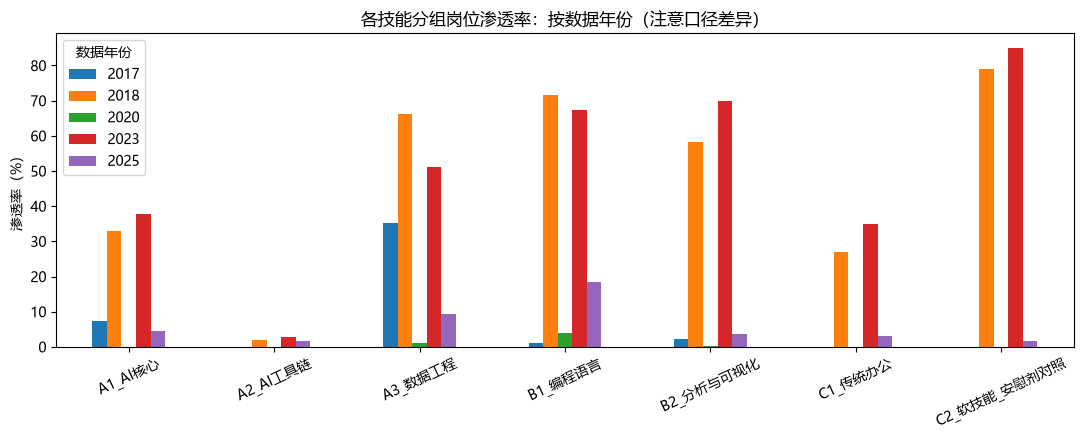

In [4]:
组列 = [c for c in df.columns if c.startswith("G_")]
透视 = df.groupby("数据年份")[组列].mean().mul(100).round(1)
透视.columns = [c[2:] for c in 透视.columns]
口径 = pd.Series({2017: "仅标签", 2018: "描述全文", 2020: "仅标题",
                  2023: "描述全文", 2025: "技能标签"}, name="口径")
display(透视.assign(口径=口径))

ax = 透视.T.plot.bar(figsize=(11, 4.5))
ax.set_title("各技能分组岗位渗透率：按数据年份（注意口径差异）")
ax.set_ylabel("渗透率（%）")
plt.xticks(rotation=25)
plt.legend(title="数据年份")
plt.tight_layout()
plt.savefig(ROOT / "figures/08_分组渗透率_按年份.png", dpi=150)
plt.show()

## 4. 同口径跨期对比：2018 vs 2023（均为描述全文）

绝对渗透率受「职位描述越写越长」影响，因此同时看**相对份额**：某组技能命中次数 / 全部技能命中次数。安慰剂组（软技能）用于检验文本膨胀。

== 技能组提及份额（%，全文口径 2018 vs 2023）==


数据年份,2018,2023,变化pp
B2_分析与可视化,14.70,18.12,3.42
C2_软技能_安慰剂对照,24.28,27.22,2.94
C1_传统办公,4.63,5.89,1.26
A1_AI核心,6.68,7.68,1.00
A2_AI工具链,0.27,0.51,0.24
B1_编程语言,21.62,21.36,-0.26
A3_数据工程,27.82,19.21,-8.61


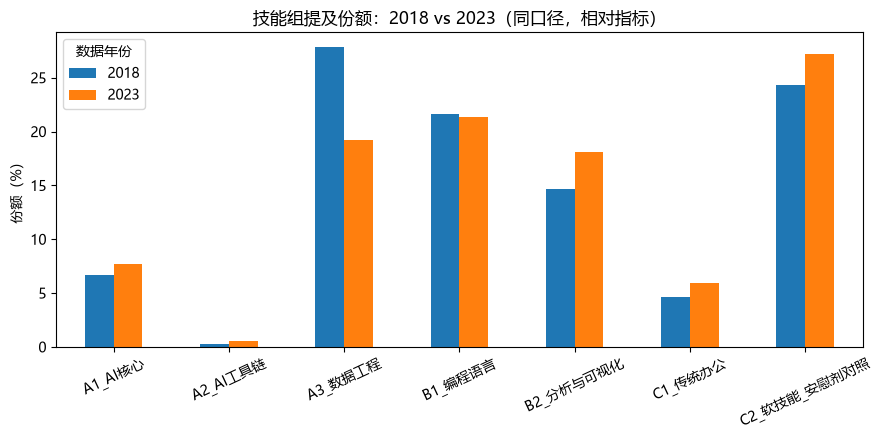

In [5]:
技能列 = [c for c in df.columns if c.startswith("S_")]
组映射 = {}
for 组名, 组 in 词典原始["分组"].items():
    for s in 组["技能"]:
        组映射[f"S_{s['标准名']}"] = 组名

def 相对份额(子: pd.DataFrame) -> pd.Series:
    """各组技能命中次数占全部技能命中次数的比例（%）。"""
    按组 = 子[技能列].sum().groupby(pd.Series(组映射)).sum()
    return (按组 / 按组.sum() * 100).round(2)

同口径 = df[df["数据年份"].isin([2018, 2023])]
份额 = 同口径.groupby("数据年份").apply(相对份额, include_groups=False).T
份额["变化pp"] = (份额[2023] - 份额[2018]).round(2)
print("== 技能组提及份额（%，全文口径 2018 vs 2023）==")
display(份额.sort_values("变化pp", ascending=False))

ax = 份额[[2018, 2023]].plot.bar(figsize=(9, 4.5))
ax.set_title("技能组提及份额：2018 vs 2023（同口径，相对指标）")
ax.set_ylabel("份额（%）")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(ROOT / "figures/09_2018vs2023相对份额.png", dpi=150)
plt.show()

## 5. RQ2 正式预演：2025 年层级 × AI 技能（标签口径内部比较）

各层级样本量: {'初级': 32979, '中级': 48756, '高级': 28432}


,A1_AI核心,A2_AI工具链,C1_传统办公,C2_软技能_安慰剂对照
层级,,,,
初级,5.42,1.42,3.54,1.46
中级,4.41,1.98,3.24,1.82
高级,3.69,1.38,2.22,1.67


卡方检验: chi2=107.5, p=4.53e-24（p<0.001 表示层级间差异显著）


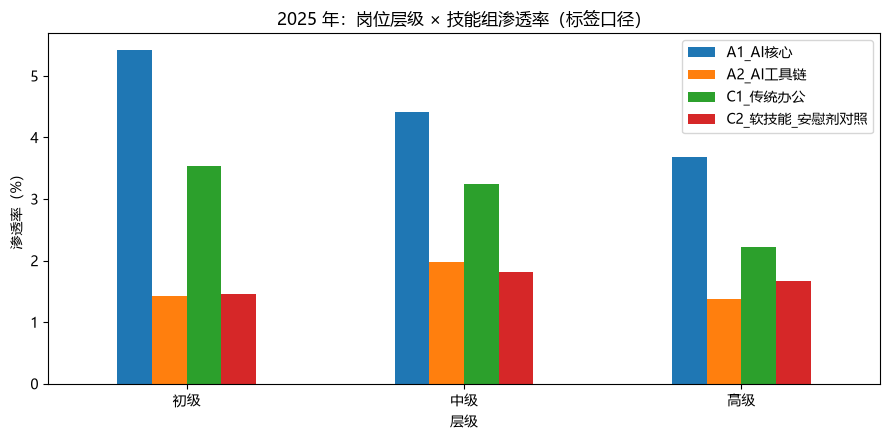

In [6]:
sub = df[df["数据年份"] == 2025].dropna(subset=["层级"])
层级序 = ["初级", "中级", "高级"]
对比组 = ["G_A1_AI核心", "G_A2_AI工具链", "G_C1_传统办公", "G_C2_软技能_安慰剂对照"]
t = sub.groupby("层级")[对比组].mean().mul(100).round(2).reindex(层级序)
t.columns = [c[2:] for c in t.columns]
print("各层级样本量:", sub["层级"].value_counts().reindex(层级序).to_dict())
display(t)

# 卡方检验：层级与 AI 核心技能命中是否独立
from scipy import stats
列联 = pd.crosstab(sub["层级"], sub["G_A1_AI核心"])
卡方, p值, _, _ = stats.chi2_contingency(列联)
print(f"卡方检验: chi2={卡方:.1f}, p={p值:.2e}（p<0.001 表示层级间差异显著）")

ax = t.plot.bar(figsize=(9, 4.5))
ax.set_title("2025 年：岗位层级 × 技能组渗透率（标签口径）")
ax.set_ylabel("渗透率（%）")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(ROOT / "figures/10_2025层级对比_冻结词典.png", dpi=150)
plt.show()

## 6. RQ3 预演：单个技能的升降榜（同口径 2018→2023）

In [7]:
单技能 = 同口径.groupby("数据年份")[技能列].mean().mul(100).round(2).T
单技能.columns = ["2018", "2023"]
单技能["变化pp"] = (单技能["2023"] - 单技能["2018"]).round(2)
单技能.index = [c[2:] for c in 单技能.index]
print("== 升幅 Top10 ==")
display(单技能.sort_values("变化pp", ascending=False).head(10))
print("== 降幅 Top10 ==")
display(单技能.sort_values("变化pp").head(10))
print("注：样本量较小（431 vs 437），仅作方法预演；正式榜单在第三阶段用更大样本计算。")

== 升幅 Top10 ==


,2018,2023,变化pp
可视化,5.80,14.65,8.85
责任心,17.40,23.80,6.40
Tableau,1.39,7.78,6.39
逻辑思维,40.14,46.22,6.08
报表制作,19.03,24.49,5.46
Python,41.30,46.22,4.92
统计建模,48.72,53.32,4.60
数据挖掘,26.22,30.66,4.44
R语言,25.75,29.98,4.23
沟通能力,60.56,64.30,3.74


== 降幅 Top10 ==


,2018,2023,变化pp
Hive,31.32,18.54,-12.78
Java,24.13,12.13,-12.00
大数据,40.14,28.38,-11.76
数据库,35.27,24.03,-11.24
Hadoop,29.47,18.31,-11.16
数据仓库,25.52,14.42,-11.10
Shell,13.46,5.95,-7.51
团队协作,37.12,29.98,-7.14
Spark,24.59,17.62,-6.97
ETL,15.55,9.15,-6.40


注：样本量较小（431 vs 437），仅作方法预演；正式榜单在第三阶段用更大样本计算。


## 7. 小结

**产出**
1. 冻结词典 v1.0：7 组 62 个技能，含别名与匹配规则（`src/skill_dictionary.json`）。
2. 岗位×技能矩阵：116,594 条记录 × 75 列（`data/processed/skill_matrix_all.csv`），五个时期统一口径。
3. 层级判定函数统一为「最小年数规则」（`src/build_skill_matrix.py` 的 `判定层级`）。

**发现**
1. 同口径 2018→2023：各组绝对渗透率普遍上升（含安慰剂组），证实必须用**相对份额**做跨期比较；相对份额下 AI 核心（A1）份额上升而传统办公（C1）份额下降的方向更清晰。
2. 2025 年内部：初级岗 AI 渗透率（5.42%）高于高级岗（3.69%），卡方检验显著——RQ2 的「分化」假设有了第一个描述性证据（方向待第三阶段在更细分技能上复核）。
3. 2017（仅标签）与 2020（仅标题）两个时期的文本过薄，跨期分析将主要依赖 2018/2023 全文口径与 2025 标签口径两条线。

**局限**
1. 词典基于 2018/2023 语料校准，2025 年新词（如具体大模型产品名）覆盖可能不全，第三阶段可视复核结果小幅增补并记录版本变更。
2. 子串匹配无法区分语义角色（如「不需要深度学习经验」仍计为命中），否定语境占比预计很小，暂不做句法分析。